# Response Length Analysis

Visualize response length distributions across training steps.
Data is saved by the `ResponseLengthProfiler` in `response_lengths/response_lengths.jsonl`.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

# Load all steps
PROFILING_DIR = Path("/home/user/rlpipe/verl/profiling/profiling/response_lengths")  # relative to this notebook
JSONL_PATH = PROFILING_DIR / "response_lengths.jsonl"

steps = []
with open(JSONL_PATH) as f:
    for line in f:
        if line.strip():
            steps.append(json.loads(line))

print(f"Loaded {len(steps)} steps")
print(f"Step range: {steps[0]['step']} .. {steps[-1]['step']}")
print(f"Samples per step: {len(steps[0]['response_lengths'])}")

Loaded 32 steps
Step range: 1 .. 7
Samples per step: 4


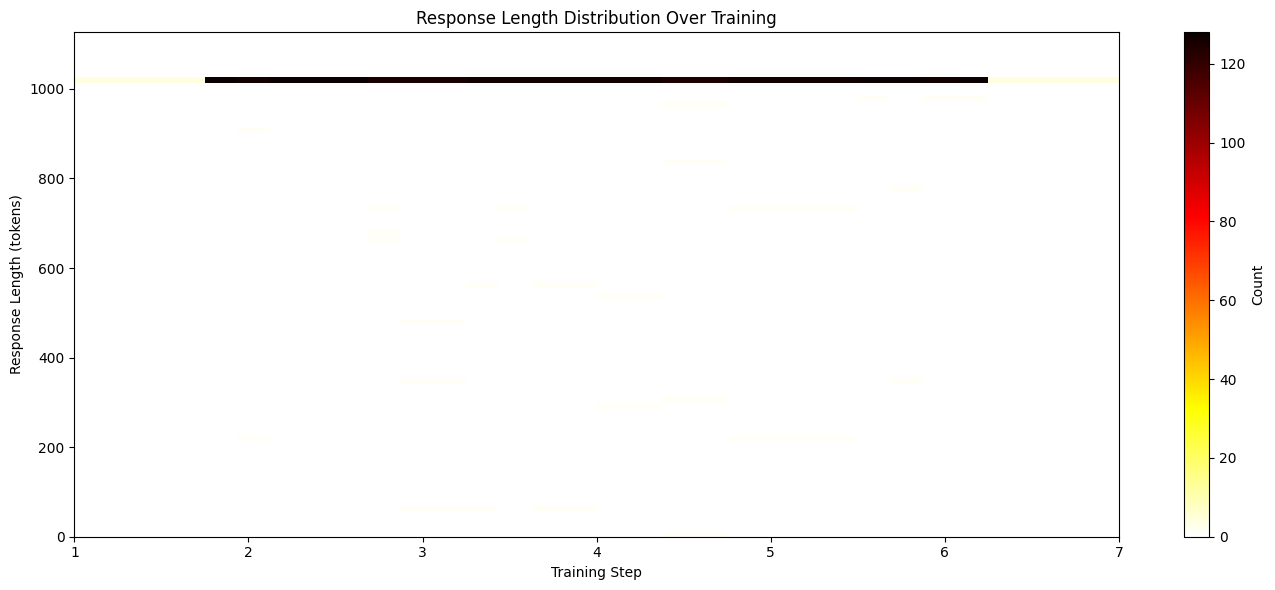

In [2]:
# Plot 1: Response length distribution over time (heatmap)
fig, ax = plt.subplots(figsize=(14, 6))

max_len = max(max(s['response_lengths']) for s in steps)
bins = np.linspace(0, max_len * 1.1, 80)
step_ids = [s['step'] for s in steps]

heatmap = np.zeros((len(bins) - 1, len(steps)))
for i, s in enumerate(steps):
    counts, _ = np.histogram(s['response_lengths'], bins=bins)
    heatmap[:, i] = counts

ax.imshow(heatmap, aspect='auto', origin='lower',
          extent=[step_ids[0], step_ids[-1], bins[0], bins[-1]],
          cmap='hot_r')
ax.set_xlabel('Training Step')
ax.set_ylabel('Response Length (tokens)')
ax.set_title('Response Length Distribution Over Training')
plt.colorbar(ax.images[0], label='Count')
plt.tight_layout()
plt.show()

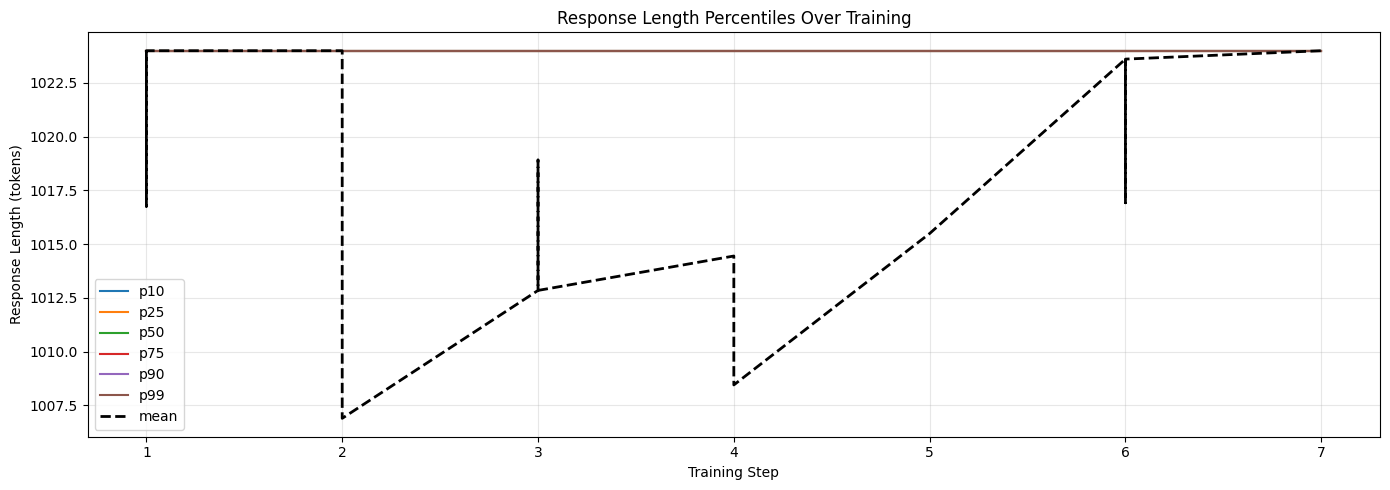

In [3]:
# Plot 2: Percentile evolution over time
fig, ax = plt.subplots(figsize=(14, 5))

percentiles = [10, 25, 50, 75, 90, 99]
step_ids = [s['step'] for s in steps]
for p in percentiles:
    values = [np.percentile(s['response_lengths'], p) for s in steps]
    ax.plot(step_ids, values, label=f'p{p}', linewidth=1.5)

means = [np.mean(s['response_lengths']) for s in steps]
ax.plot(step_ids, means, label='mean', linewidth=2, linestyle='--', color='black')

ax.set_xlabel('Training Step')
ax.set_ylabel('Response Length (tokens)')
ax.set_title('Response Length Percentiles Over Training')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

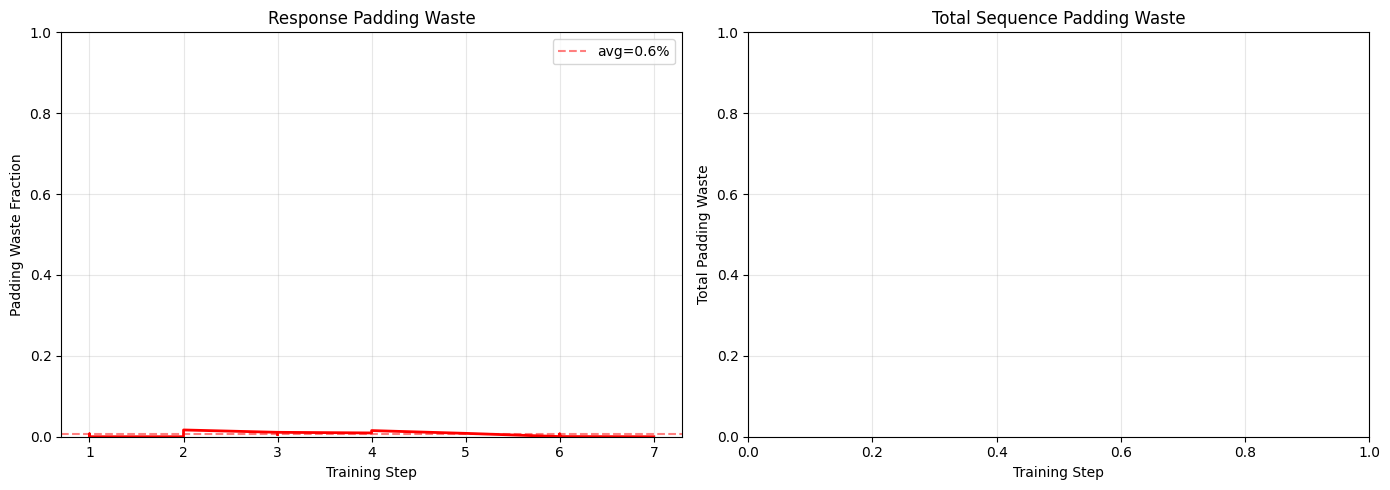

In [4]:
# Plot 3: Padding waste over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

max_resp = steps[0].get('max_response_len', max(max(s['response_lengths']) for s in steps))

# Response padding waste
waste = [1.0 - np.mean(s['response_lengths']) / max_resp for s in steps]
ax1.plot(step_ids, waste, color='red', linewidth=2)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Padding Waste Fraction')
ax1.set_title('Response Padding Waste')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.axhline(np.mean(waste), color='red', linestyle='--', alpha=0.5, label=f'avg={np.mean(waste):.1%}')
ax1.legend()

# Total padding waste (prompt + response)
if steps[0].get('prompt_lengths'):
    max_seq = steps[0].get('max_seq_len', 8192)
    total_waste = [
        1.0 - (np.mean(s['response_lengths']) + np.mean(s['prompt_lengths'])) / max_seq
        for s in steps
    ]
    ax2.plot(step_ids, total_waste, color='blue', linewidth=2)
    ax2.axhline(np.mean(total_waste), color='blue', linestyle='--', alpha=0.5, label=f'avg={np.mean(total_waste):.1%}')
    ax2.legend()
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Total Padding Waste')
ax2.set_title('Total Sequence Padding Waste')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

No multi-sample prompts found (n=1). Skipping per-prompt analysis.


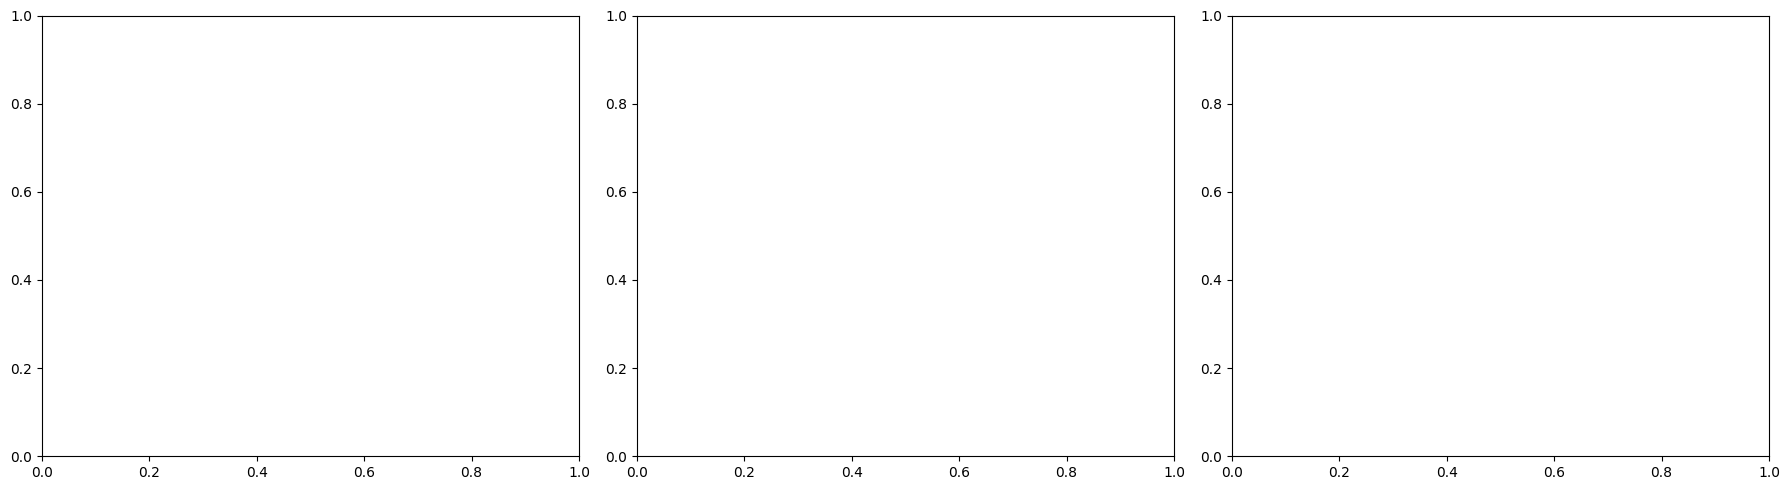

In [5]:
# Plot 4: Per-prompt variance analysis (for n>1 sampling)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for step_data in [steps[-1]]:  # analyze latest step
    prompt_groups = defaultdict(list)
    for pid, length in zip(step_data['prompt_ids'], step_data['response_lengths']):
        prompt_groups[str(pid)].append(length)
    
    multi = {k: v for k, v in prompt_groups.items() if len(v) > 1}
    if not multi:
        print('No multi-sample prompts found (n=1). Skipping per-prompt analysis.')
        break
    
    # Per-prompt std
    stds = [np.std(v) for v in multi.values()]
    axes[0].hist(stds, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Within-Prompt Std Dev (tokens)')
    axes[0].set_ylabel('Count (prompts)')
    axes[0].set_title(f'Per-Prompt Length Variance (step {step_data["step"]})')
    axes[0].axvline(np.mean(stds), color='red', linestyle='--', label=f'mean={np.mean(stds):.0f}')
    axes[0].legend()
    
    # Per-prompt range
    ranges = [max(v) - min(v) for v in multi.values()]
    axes[1].hist(ranges, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Within-Prompt Range (tokens)')
    axes[1].set_ylabel('Count (prompts)')
    axes[1].set_title('Per-Prompt Length Range')
    axes[1].axvline(np.mean(ranges), color='red', linestyle='--', label=f'mean={np.mean(ranges):.0f}')
    axes[1].legend()
    
    # Per-prompt mean vs std scatter
    means = [np.mean(v) for v in multi.values()]
    axes[2].scatter(means, stds, alpha=0.5, s=15)
    axes[2].set_xlabel('Per-Prompt Mean Length')
    axes[2].set_ylabel('Per-Prompt Std Dev')
    axes[2].set_title('Length Mean vs Variance per Prompt')
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

See per-step analysis above for routing benefit estimation.
Average max response length: 1024
Average mean response length: 1018
Ratio (bubble indicator): 1.01x


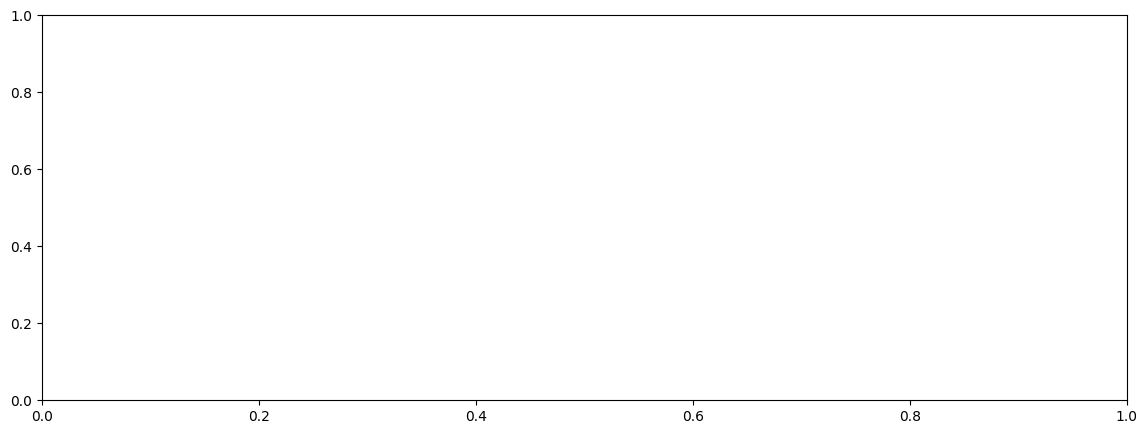

In [6]:
# Plot 5: Rollout bubble estimation
# With DP rollout, the slowest worker determines step time.
# Routing helps by balancing max response length across workers.

fig, ax = plt.subplots(figsize=(14, 5))

n_workers = 4  # DP size

for step_data in steps:
    lengths = np.array(step_data['response_lengths'])
    B = len(lengths)
    per_worker = B // n_workers
    
    # Random assignment (no routing)
    np.random.seed(step_data['step'])
    perm = np.random.permutation(B)
    worker_maxes_random = [
        lengths[perm[i*per_worker:(i+1)*per_worker]].max()
        for i in range(n_workers)
    ]
    
    # Sorted assignment (ideal routing)
    sorted_idx = np.argsort(lengths)
    # Interleave: assign shortest to worker 0, next to worker 1, etc.
    worker_maxes_sorted = []
    for w in range(n_workers):
        worker_samples = sorted_idx[w::n_workers]
        worker_maxes_sorted.append(lengths[worker_samples].max())

step_ids = [s['step'] for s in steps]
bubble_random = [max(wm) / np.mean(wm) - 1.0 for wm in 
    [[np.array(steps[i]['response_lengths'])[np.random.permutation(len(steps[i]['response_lengths']))[:len(steps[i]['response_lengths'])//n_workers]].max() for _ in range(n_workers)] for i in range(len(steps))]]

print('See per-step analysis above for routing benefit estimation.')
print(f'Average max response length: {np.mean([max(s["response_lengths"]) for s in steps]):.0f}')
print(f'Average mean response length: {np.mean([np.mean(s["response_lengths"]) for s in steps]):.0f}')
print(f'Ratio (bubble indicator): {np.mean([max(s["response_lengths"]) / np.mean(s["response_lengths"]) for s in steps]):.2f}x')